In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
import struct
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from pathlib import Path


In [2]:
data = get_data()
config, config_str = get_hmc_config(find_min = False, bias = "unified", cap = False, temp = True, umbrella = True)
find_min_config, config_find_min_str = get_hmc_config(find_min = True)
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))
print(config["nl"])

101


In [3]:
base_dir = Path.cwd()

samples = (base_dir / f"../../../../output/age_depth_OPES/samples_{config_str}.npy").resolve() # Continue fixing paths in the c file and potentially in some other file, push and then try again on Andreas computer.
energy_values = (base_dir / f"../../../../output/age_depth_OPES/energy_{config_str}.npy").resolve()
bias_values = (base_dir / f"../../../../output/age_depth_OPES/bias_{config_str}.npy").resolve()
resampled_samples = (base_dir / f"../../../../output/age_depth_OPES/resamp_{config_str}.npy").resolve()

samples = np.load(samples)
energy_values = np.load(energy_values)
bias_values = np.load(bias_values)
resampled_samples = np.load(resampled_samples)


In [4]:
print(energy_values)

[[ 98.79401924  98.79401924  98.79401924 ... 175.61878281 183.7309716
  179.54965517]
 [137.69170907 125.24645429 133.06597506 ... 247.01775222 257.60498229
  253.94961521]
 [124.80920508 135.93995532 169.62316638 ... 323.9227914  316.890075
  313.42060344]
 [120.60080042 120.60080042 120.60080042 ... 295.97214963 299.25794493
  287.48397898]
 [114.41913706 158.01853532 203.38760715 ... 409.76703859 402.06493751
  384.02668468]]


In [5]:
nl = config["nl"] if config["nl"] != None else 1
nl2 = config["nl"] if config["npc"] == 2 else 1
nt = config["nt"] if config["nt"] != None else 1
temp_colors = plt.cm.viridis(np.linspace(0,1, nt))


In [ ]:
# base_dir = Path.cwd()

# files = [(base_dir / f"../../../../output/age_depth_OPES/deltaF_chain{i}_{config_str}.bin").resolve() for i in range(config["nch"])]
# # Read every 10th element along the first axis (ns)
# stride = 10
# deltaF = []

# for f in files:
#     dF_data = np.fromfile(f, dtype=np.float64)
#     # reshape to full dimensions first
#     dF_data = dF_data.reshape(config["ns"], nl, nl2, nt)
#     # take every 10th element along the first axis
#     deltaF.append(dF_data[::stride])

# deltaF = np.array(deltaF)
# print(deltaF.shape)

MemoryError: Unable to allocate 925. MiB for an array with shape (121200000,) and data type float64

In [7]:
print("Reweighting energies for each temp\n")

if nt > 1:
    factors = np.arange(nt) / (nt - 1)
else:
    factors = np.array([0.0])

temp_centers = config["sbt"] * (config["ebt"] / config["sbt"]) ** factors

# Compute betas
betas = 1.0 / temp_centers

# Initial beta
beta0 = 1.0 / config["sbt"]
energy_samples = []
weights = []

for j in range(config["nt"]):
    temp_energy_samples = []
    weights = np.exp(-(betas[j] - beta0) * energy_values + bias_values)
    for i in range(config["nch"]):
        weights_i = weights[i, config["co"]:] / sum(weights[i, config["co"]:])
        indices = np.random.choice(
            np.arange(config["co"], len(weights_i) + config["co"]),
            size=int(len(weights_i)),
            replace=True,
            p=weights_i,
        )
        print(f"Chain {i} done resampling")
        temp_energy_samples.append(energy_values[i, indices])
    energy_samples.append(temp_energy_samples)
        
energy_samples = np.array(energy_samples)
print(np.shape(energy_samples))

Reweighting energies for each temp

Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chai

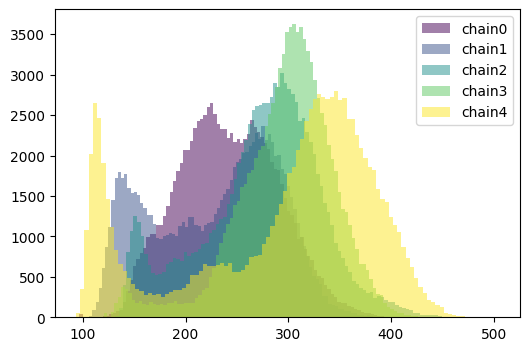

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(energy_values[i, :], color = colors[i], alpha = 0.5, label = f"chain{i}", bins = 100)
plt.legend()
plt.show()   

7213.3897741243545
4383959399746.993
1.0244858137832599e+21
7.521313680563079e+28
7.199814716596701e+35
1.0030930314449164e+42
2.569689182410565e+47
1.4533783661133716e+52
2.104701105885646e+56
9.035156298840883e+59
1.3863016147777497e+63
1.0910904599186878e+66


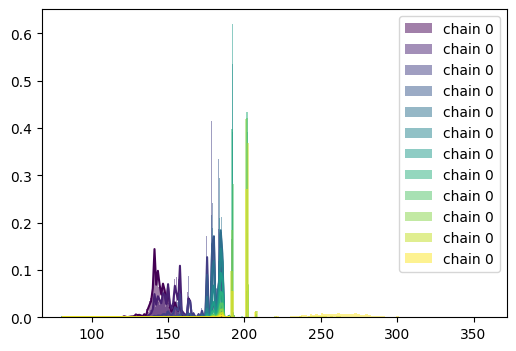

62992.150382244385
3472109874177.4946
9.454766346875985e+20
4.72005089729772e+28
3.375191579463899e+35
4.902780994390844e+41
1.467986146863337e+47
9.313054669454039e+51
1.448546121889938e+56
6.555612417786294e+59
1.0080874176478467e+63
6.017023109328245e+65


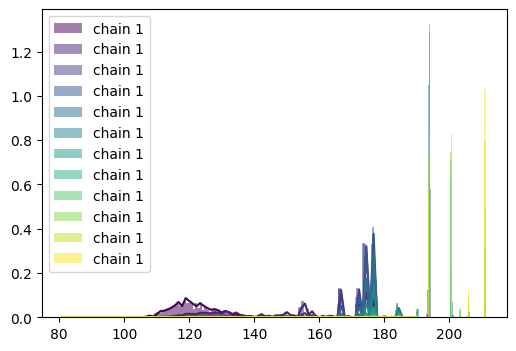

171102.6898989186
384643474086253.3
8.576500454481877e+23
2.5530351979860304e+32
9.346556784952842e+39
5.072745736451473e+46
4.910700548479399e+52


In [ ]:
limit_grid = np.linspace(80, 190, 100)
bin_grid = limit_grid[:-1]

for k in range(config["nch"]):
    fig, ax = plt.subplots(figsize=(6, 4))
    for j in range(config["nt"]):
        # bin_values = np.zeros_like(bin_grid)
        # weights = np.exp(-(betas[j] - beta0) * energy_values[k, :] + bias_values[k, :])
        # for bin_idx in range(len(bin_grid)):
        #     for i, e in enumerate(energy_values[k, :]):
        #         if e > limit_grid[bin_idx] and e < limit_grid[bin_idx + 1]:
        #             bin_values[bin_idx] += weights[i]
        # print(sum(weights))
        # bin_values /= sum(weights)
        # # print(bin_values)
        # ax.plot(bin_grid + ((190-80)/100), bin_values, color = temp_colors[j])
        ax.hist(energy_samples[j, k, :], bins = 100, color = temp_colors[j], label = f"chain {k}", alpha = 0.5, density = True)
    plt.legend()
    plt.show()





12


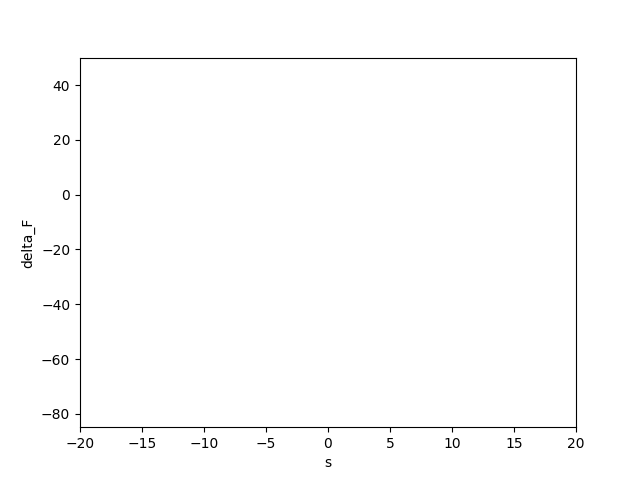

In [ ]:
%matplotlib widget

print(config["nt"])
if (not (config["npc"] == None)):

    if config["npc"] == 2:
        xcoords = np.linspace(config["sb"], config["eb"], config["nl"])
        ycoords = np.linspace(config["sb"], config["eb"], config["nl"])

        X, Y = np.meshgrid(xcoords, ycoords)

        for i in range(config["nch"]):
            last_delta_F = np.squeeze(deltaF[i, -1, :, :, 9])
            indices = np.unravel_index(np.argmin(last_delta_F), last_delta_F.shape)
            print(deltaF[i, :, :, 0])
            print(f"Chain {i} min deltaF at: {indices}")
            print(xcoords[indices[0]])
            print(ycoords[indices[1]])
            print(f"{i}\n")
            print(last_delta_F[last_delta_F<50])
            plt.figure(figsize=(6,5))
            pcm = plt.pcolormesh(X, Y, last_delta_F.T, shading='auto', cmap='viridis') # This looks flipped, could be the plotting, but could also be the indexing.
            plt.colorbar(pcm, label='Value')
            plt.xlabel('X coordinate')
            plt.ylabel('Y coordinate')
            plt.title('2D Plot with coordinates')
            plt.show()
    if config["npc"] == 1:
        xcoords = np.linspace(config["sb"], config["eb"], config["nl"])

        fig, ax = plt.subplots()

        lines = []

        for j in range(nt):
            line, = ax.plot([], [], lw=2, label=f"T{j}", color = temp_colors[j])
            lines.append(line)
        ax.set_xlim(config["sb"], config["eb"])
        ax.set_ylim(np.min(deltaF), np.max(deltaF))

        ax.set_xlabel("s")
        ax.set_ylabel("delta_F")
        shorter_deltaF = deltaF[:, ::100, : , :, :]

        def update(frame):
            i = frame
            for j in range(nt):
                sample_delta_F = np.squeeze(shorter_deltaF[0, i, :, 0, j])
                lines[j].set_data(xcoords, sample_delta_F)
            ax.set_title(f"sample i={i}")
            return lines,
    
        frames = config["ns"]  # number of frames
        ani = FuncAnimation(fig, update, frames=frames, blit=False, interval=100, repeat = False)

        plt.show()

In [ ]:
# starting_points = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/samples_min_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")
# starting_energies = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/Emin_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")
starting_energies_path = (base_dir / f"../../../../output/age_depth_OPES/Emin_{config_find_min_str}.npy").resolve()
starting_energies = np.load(starting_energies_path)
starting_points_path = (base_dir / f"../../../../output/age_depth_OPES/samples_min_{config_find_min_str}.npy").resolve()
starting_points= np.load(starting_points_path)
print(starting_energies)

[ 95.82593999 160.81503149  98.51794836 103.03485398 101.85631173
  96.41480715 175.364578    93.98629295 100.27035141 103.30341829
  96.9760657   92.85025439  98.77664828  95.47403137 166.73402062
 106.08955114 102.55836007  96.41503312  97.06198286 102.61538138
  97.22144971 166.97508882  98.25586272 159.29191304]


In [ ]:
print(starting_points)
# print(np.sort(starting_energies))
sp_mean= np.mean(starting_points, axis = 0)
sp = starting_points-sp_mean
cov = np.cov(sp, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

print(eigenvalues)
print(np.sum(eigenvalues[0:4])/np.sum(eigenvalues))
var_ratio = eigenvalues[0] / np.sum(eigenvalues)
var2_ratio = eigenvalues[1] / np.sum(eigenvalues)
print("Main direction at problem:", pc1[20:25])
print(np.abs(pc1) > 0.1)
print("Main direction:", pc1[np.abs(pc1) > 0.1])

print(np.linalg.norm(pc1))
print(30 * np.sum(pc1[pc1>0]))
print(30 * np.sum(pc1[pc1<0]))

[[ 2.79418374  4.52858206  5.91163311 ... 15.73609938  5.46834945
   7.18668404]
 [ 3.13752277  2.735891    0.1999274  ... 14.29024138  6.35385465
   7.11896571]
 [ 2.81473448  4.55725012  5.67717706 ... 16.52889703  4.75174367
   7.11554067]
 ...
 [ 3.23114209  2.48987415  0.10409423 ... 15.78057255  4.77436232
   7.28439606]
 [ 2.80160457  4.4717735   5.70351598 ... 16.23676995  5.81824473
   7.15904583]
 [ 3.34732639  2.62277076  0.10482999 ... 15.93404328  4.91552015
   7.10454998]]
[ 2.12432906e+01  1.25917413e+01  7.35460259e+00  2.78447744e+00
  2.20309116e+00  9.95535665e-01  4.80865255e-01  4.02794040e-01
  3.00687548e-01  2.74161443e-01  1.85325715e-01  1.71530300e-01
  1.32132616e-01  9.79456360e-02  8.47269678e-02  6.50038512e-02
  5.12646374e-02  4.40106198e-02  3.56650602e-02  2.48021028e-02
  1.74941425e-02  1.48842804e-02  1.06871371e-02  1.95648036e-15
  9.15205860e-16  7.74726900e-16  4.18625995e-16  3.65118007e-16
  2.51763075e-16  2.38408187e-16  9.11332116e-17  7.2

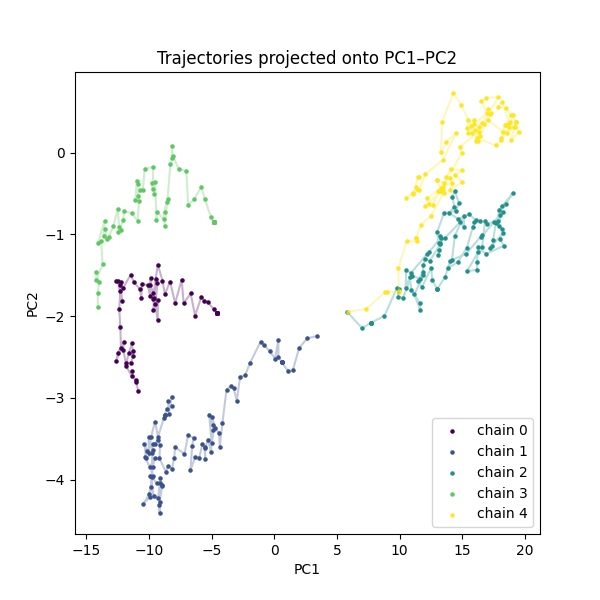

In [ ]:
proj = []
for chain in range(samples.shape[0]):
    traj = samples[chain]
    traj_centered = traj - sp_mean
    coords = np.stack([traj_centered @ pc1,
                       traj_centered @ pc2], axis=1) # This should be the same as what i get when i print in C, maybe the indexing becomes wrong when i send in the pcs?
    proj.append(coords)

# Plot
fig, ax = plt.subplots(figsize=(6,6))

for chain, coords in enumerate(proj):
    ax.plot(coords[:,0], coords[:,1], alpha=0.3, color=colors[chain])
    ax.scatter(coords[:,0], coords[:,1], s=5, color=colors[chain], label=f"chain {chain}")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Trajectories projected onto PC1–PC2") # Something is weird, adding the exploration in pc2 makes it explore worse in pc1, something is still wrong.
ax.legend()
plt.show()

In [ ]:
print(np.shape(resampled_samples))
print(np.shape(samples))

(5, 100, 50)
(5, 100, 50)


In [ ]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [ ]:
print(energy_values)

[[ 98.79401924  98.79401924  98.79401924  98.79401924  98.79401924
   98.79401924  98.79401924  98.79401924  98.79401924  98.79401924
   98.79401924  98.79401924  98.79401924  98.79401924  98.79401924
   98.79401924  98.79401924  98.79401924  98.79401924  98.79401924
   98.79401924  98.79401924  98.79401924  98.79401924  98.79401924
   98.79401924  98.79401924  98.79401924  98.79401924  98.79401924
   98.79401924  98.79401924  98.79401924  98.79401924  98.79401924
   98.79401924  98.79401924  98.79401924  98.79401924  98.79401924
   98.79401924  98.79401924  98.79401924  93.34355929 114.468281
  134.85102249 110.53072186 110.45800902 117.96424701 125.19722374
  135.03612861 132.48020211 149.45949168 159.07624178 149.71234443
  173.0435727  178.48838282 193.57566405 165.8545158  150.49741966
  165.83282396 156.04601764 159.74764363 148.48624906 176.94935603
  174.83955289 153.24658042 145.22809042 149.01737689 172.76155963
  176.29775668 181.12883409 190.62553092 186.31738123 239.259691

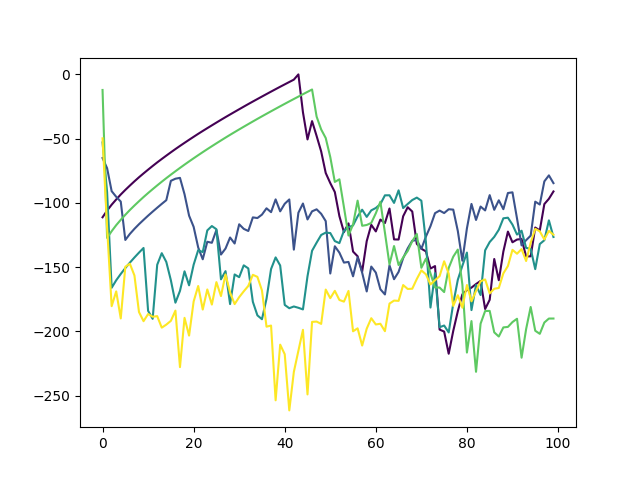

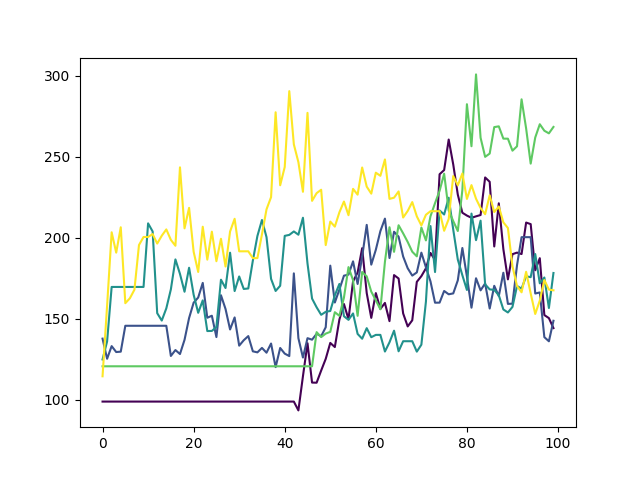

In [ ]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:], color = colors[i])
plt.show()


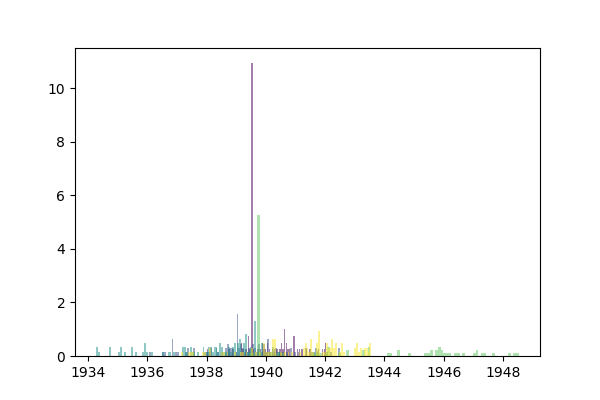

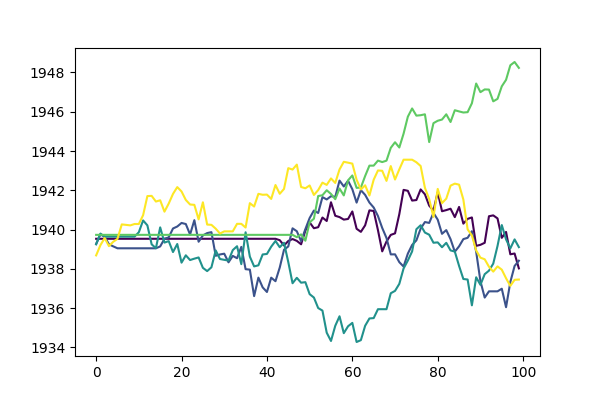

In [ ]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :4], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.show()

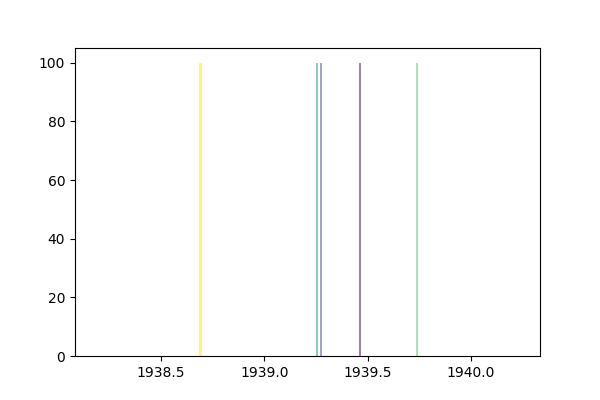

In [ ]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :4], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

In [ ]:
resampled_samples = resampled_samples[:,::100,:]

In [ ]:
print(np.max(bias_values))

-0.03775326396730069


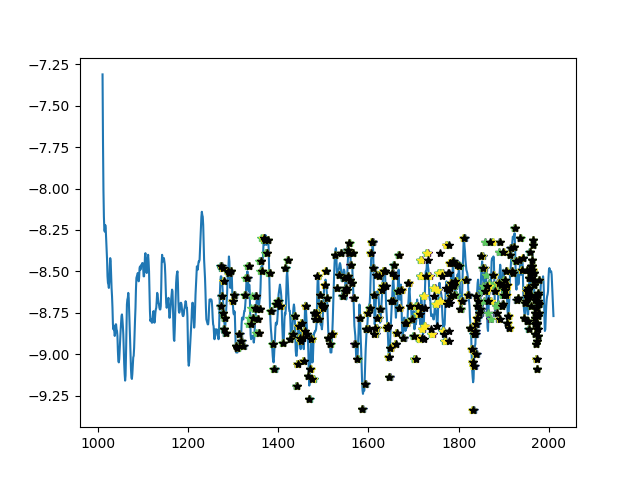

In [ ]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["nch"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [ ]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

c:\Users\hanna\Desktop\PhD\Bacon\bacon_venv\Lib\site-packages\arviz\data\base.py:272: UserWarning: More chains (5) than draws (1). Passed array should have shape (chains, draws, *shape)
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (5, 1), minimum_shape: (chains=1, draws=4)


        mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]    2.81  0.02    2.78     2.84        NaN      NaN       NaN       NaN   
x[1]    4.58  0.14    4.45     4.74        NaN      NaN       NaN       NaN   
x[2]    5.81  0.15    5.68     6.03        NaN      NaN       NaN       NaN   
x[3]    6.17  0.11    6.04     6.34        NaN      NaN       NaN       NaN   
x[4]    6.69  0.33    6.36     7.05        NaN      NaN       NaN       NaN   
x[5]    4.85  0.18    4.54     4.97        NaN      NaN       NaN       NaN   
x[6]    4.25  0.29    3.93     4.51        NaN      NaN       NaN       NaN   
x[7]    3.32  0.95    2.55     4.37        NaN      NaN       NaN       NaN   
x[8]    4.49  2.20    2.84     6.99        NaN      NaN       NaN       NaN   
x[9]    6.97  2.07    5.24     9.25        NaN      NaN       NaN       NaN   
x[10]   6.11  1.00    4.95     7.08        NaN      NaN       NaN       NaN   
x[11]   8.39  4.39    3.67    12.38        NaN      

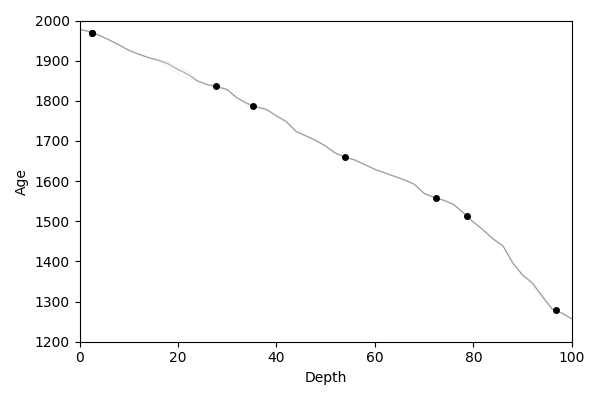

In [ ]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
# for i, c in enumerate(config["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

In [ ]:
depths = np.sort(np.hstack((0, data["d18O_depths"])))
ages = np.flip(np.hstack((data["theta"], data["true_ages_D18O"]))) # why are they not sorted correctly?
# print(depths)
# print(ages)
sed_rates = [0]
theta = data["theta"]

pre_age = theta
pre_depth = 0
for i in range(1, config["N"] + 1):
    idx = np.searchsorted(depths, config["cs"][i])
    # print(np.sort(depths))
    # print(config["cs"][i])
    # print(idx)
    if idx < len(depths):
        upper_depth = depths[idx - 1]
        age = ages[idx - 1] + ((ages[idx] - ages[idx - 1])/(depths[idx] - depths[idx - 1]))*(config["cs"][i] - depths[idx-1])
        sed_rates.append((pre_age - age) / (config["cs"][i] - config["cs"][i-1]))
        pre_age = age
    else:
        sed_rates.append(config["a"] / config["b"])


print(sed_rates)
exp_ages = theta - np.cumsum(sed_rates) * config["dc"]
print(exp_ages)
print(np.max(sed_rates))

[0, np.float64(2.961999999999989), np.float64(4.918999999999983), np.float64(5.424000000000092), np.float64(7.48792682926819), np.float64(6.232073170731724), np.float64(4.960348837209267), np.float64(3.886079734219379), np.float64(2.3600487012986378), np.float64(3.077159090909049), np.float64(5.722077922077915), np.float64(10.704053156146301), np.float64(8.34939922480612), np.float64(3.580958333333342), np.float64(2.1794903846154057), np.float64(5.24633699633705), np.float64(10.239729437229357), np.float64(6.853863636363712), np.float64(2.800787878787901), np.float64(2.2284166666665897), np.float64(1.326249999999959), np.float64(3.7012500000000728), np.float64(11.959886363636315), np.float64(13.616363636363644), np.float64(9.235416666666652), np.float64(8.99635416666672), np.float64(7.4015624999999545), np.float64(4.2762943262411), np.float64(4.733872340425592), np.float64(4.755707317073188), np.float64(5.887838137472272), np.float64(6.097495361781057), np.float64(3.2143877551020523), 

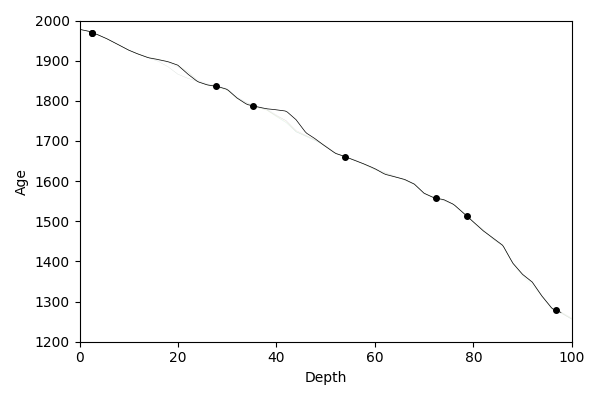

In [ ]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
# for i, c in enumerate(config["cs"]):
#     if i != config["pidx"]:
#         ax.axvline(x=c, color='k', linestyle='--')
#     else:
#         ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
# plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
# plt.plot(config["cs"], exp_ages, color = 'r', linewidth = 0.5)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.plot(data["d18O_depths"], data["true_ages_D18O"], color = 'k', linewidth=0.5)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()